# Topic modeling
En este notebook se va a demostrar el uso de distintos modelos de extracción de temáticas (*topic modeling*) en un conjunto de textos de ejemplo sencillo (sin Deep Learning, para comprender sus limitaciones).

In [2]:
!pip install textacy
#!python -m spacy download es_core_news_sm

  Using cached textacy-0.13.0-py3-none-any.whl.metadata (5.3 kB)
  Using cached cachetools-7.1.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached cytoolz-1.1.0-cp313-cp313-win_amd64.whl.metadata (5.3 kB)
  Using cached floret-0.10.5.tar.gz (70 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached jellyfish-1.2.1-cp313-cp313-win_amd64.whl.metadata (642 bytes)
  Using cached pyphen-0.17.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached toolz-1.1.0-py3-none-any.whl.metadata (5.1 kB)
Using cached textacy-0.13.0-py3-none-any.whl (210 kB)
Using cached cachetools-7.1.1-py3-none-any.whl (16 kB)
Using cached cytoolz-1.1.0-cp313-cp313-win_amd64.whl (946 kB)
Using cached jellyfish-1.2.1-cp313-cp313-win_a

  error: subprocess-exited-with-error
  
  × Building wheel for floret (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [33 lines of output]
      C:\Users\sPoKet20\AppData\Local\Temp\pip-build-env-7zlqgjzj\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the following classifiers in favor of a SPDX license expression:
      
              License :: OSI Approved :: MIT License
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
              ********************************************************************************
      
      !!
        self._finalize_license_expression()
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd64-cpython-31

In [7]:
import spacy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json

nlp=spacy.load('es_core_news_md')

### Creación del corpus
Creamos un pequeño Corpus de ejemplo formado por 8 frases cortas. Definimos una sencilla función de normalización y aplicamos esta normalización a todo el corpus.

In [ ]:
def normalize_document(doc):
    # tokenizamos el texto
    tokens = nlp(doc)
    # quitamos puntuación/espacios/stop words y cogemos el lema
    lemmas = [t.lemma_ for t in tokens if not t.is_punct and not t.is_space and not t.is_stop]
    doc = ' '.join(lemmas)
    return doc

def normalize_corpus(corpus):
    """Normaliza un corpus de documentos aplicando al función de normalización
    normalize_document() a cada documento de la lista pasada como argumento"""
    return [normalize_document(text) for text in corpus]

with open("../data_processed/conjunto_noticias_limpio.json", "r", encoding = "utf-8") as f:
    lista_noticias = json.load(f)

content_corpus = []
for noticia in lista_noticias:
    contenido = noticia['Contenido'].split(".")
    content_corpus.append(normalize_corpus(contenido))

title_corpus = [noticia['Título'] for noticia in lista_noticias]

#norm_content_corpus = [normalize_corpus(contenido) for contenido in content_corpus]
#norm_title_corpus = normalize_corpus(title_corpus)

corpus = [[titulo] + contenido for titulo, contenido in zip(title_corpus, content_corpus)]

## Topic modeling usando Scikit-learn
La librería `scikit-learn` implementa los modelos *Latent Semantic Analysis* (LSA) y *Latent Dirichlet Allocation* (LDA).  
Partimos de un modelo TF-IDF para el modelado LSA y de un modelo BoW para el modelado LDA

### Modelo LSA

In [104]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# usamos características tf-idf para LSA.

tfidf_vectorizer = []
tfidf = []
for i in range(len(corpus)):
    tfidf_vectorizer.append(TfidfVectorizer(min_df=2).fit(corpus[i]))
    tfidf.append(tfidf_vectorizer[i].transform(corpus[i]))

Definimos una función de ayuda para mostrar los resultados (términos asociados a cada tema)

In [105]:
def print_top_words(model, feature_names, n_top_words):
    """Función auxiliar para mostrar los términos más importantes
    de cada topic"""
    for topic_idx, topic in enumerate(model.components_):
        message = f"Topic #{topic_idx}: "
        message += " ".join([feature_names[i]
                             for i in topic.argsort()[:-n_top_words - 1:-1]])  # construye el texto con las palabras más importantes del topic
        print(message)
    print()

Calculamos los modelos para nuestro corpus (método `fit`) y vemos cuáles son los 3 términos con más peso para cada *topic*. Cada modelo asigna un grado de pertenencia en cada tema a cada término del vocabulario de la matriz tfidf o bow utilizada como entrada.

In [106]:
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation

# Ajustamos el modelo LSA
lsa = []
for i in range(len(corpus)):
    lsa.append(TruncatedSVD(n_components=2).fit(tfidf[i]))

# Visualicemos, por ejemplo, los resultados para la primera noticia
print("\nTopics en modelo LSA:")
tfidf_feature_names = tfidf_vectorizer[0].get_feature_names_out()
print(tfidf_feature_names)
print_top_words(lsa[0], tfidf_feature_names, 3)


Topics en modelo LSA:
['academia' 'artículo' 'barbacid' 'ciencia' 'conflicto' 'cáncer' 'decidir'
 'envío' 'financiero' 'interés' 'investigación' 'mariano' 'miembro'
 'momento' 'pna' 'publicar' 'páncreas' 'relevante' 'resultado' 'retirar'
 'revelar' 'revista' 'terapia' 'tipo' 'trabajo' 'unidos']
Topic #0: barbacid cáncer artículo
Topic #1: resultado investigación terapia



In [107]:
# Seguimos con el ejemplo de la primera noticia
for topic_idx, topic in enumerate(lsa[0].components_):
    print(f"\nTopic #{topic_idx}")
    for i, weight in enumerate(topic):
        print(f"{tfidf_feature_names[i]}: {weight:.3f}")


Topic #0
academia: 0.268
artículo: 0.268
barbacid: 0.285
ciencia: 0.146
conflicto: 0.252
cáncer: 0.275
decidir: 0.186
envío: 0.138
financiero: 0.137
interés: 0.267
investigación: 0.183
mariano: 0.230
miembro: 0.135
momento: 0.138
pna: 0.145
publicar: 0.175
páncreas: 0.218
relevante: 0.146
resultado: 0.145
retirar: 0.186
revelar: 0.138
revista: 0.175
terapia: 0.186
tipo: 0.137
trabajo: 0.214
unidos: 0.146

Topic #1
academia: -0.136
artículo: -0.136
barbacid: 0.100
ciencia: -0.185
conflicto: -0.183
cáncer: 0.196
decidir: -0.199
envío: -0.172
financiero: -0.006
interés: -0.179
investigación: 0.404
mariano: -0.003
miembro: -0.087
momento: -0.172
pna: -0.019
publicar: 0.141
páncreas: 0.096
relevante: -0.185
resultado: 0.409
retirar: -0.199
revelar: -0.172
revista: 0.141
terapia: 0.314
tipo: -0.006
trabajo: 0.305
unidos: -0.185


El método `fit` aprende la matriz de `topics` x `términos` para el corpus dado

In [108]:
lsa[0].components_.shape

(2, 26)

In [109]:
pd.DataFrame(np.round(lsa[0].components_, 4), columns=tfidf_feature_names)

,academia,artículo,barbacid,ciencia,conflicto,cáncer,decidir,envío,financiero,interés,...,páncreas,relevante,resultado,retirar,revelar,revista,terapia,tipo,trabajo,unidos
0,0.2680,0.2680,0.2854,0.1456,0.2522,0.2751,0.1865,0.1384,0.1373,0.2674,...,0.2183,0.1456,0.1454,0.1865,0.1384,0.1749,0.1863,0.1373,0.2139,0.1456
1,-0.1357,-0.1357,0.0995,-0.1851,-0.1833,0.1964,-0.1989,-0.1717,-0.0058,-0.1788,...,0.0963,-0.1851,0.4091,-0.1989,-0.1717,0.1406,0.3139,-0.0058,0.3051,-0.1851


Podemos ver el porcentaje de pertenencia a cada *topic* de cada una de los documentos asignados por el modelo con el método `transform`:

In [110]:
lsa[0].transform(tfidf[0])

array([[ 0.62890443, -0.02674259],
       [ 0.80101429, -0.25728962],
       [ 0.78300134, -0.21417543],
       [ 0.60328253,  0.1515277 ],
       [ 0.5488819 ,  0.73074139],
       [ 0.51832484,  0.57216339],
       [ 0.71037725, -0.56091378],
       [ 0.        ,  0.        ]])

In [111]:
np.round(lsa[0].transform(tfidf[0]), 4)

array([[ 0.6289, -0.0267],
       [ 0.801 , -0.2573],
       [ 0.783 , -0.2142],
       [ 0.6033,  0.1515],
       [ 0.5489,  0.7307],
       [ 0.5183,  0.5722],
       [ 0.7104, -0.5609],
       [ 0.    ,  0.    ]])

Cada fila corresponde a un documento del Corpus, y cada columna el grado de pertenencia a ese tema del documento.  
El modelo ha separado correctamente el corpus en las dos temáticas principales:

In [115]:
np.argmax(lsa[0].transform(tfidf[0]), axis=1)

array([0, 0, 0, 0, 1, 1, 0, 0])

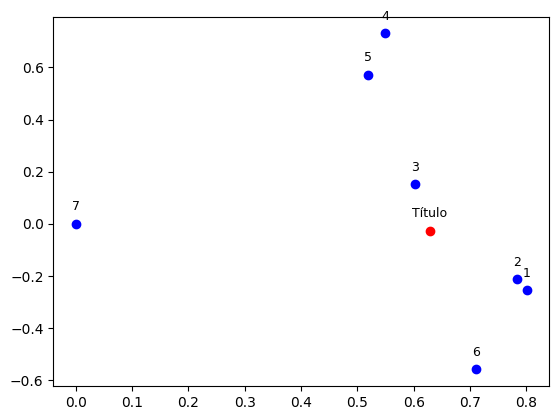

In [139]:
import matplotlib.pyplot as plt

datos = lsa[0].transform(tfidf[0])

plt.scatter(datos[0,0], datos[0,1], color="red", label="Título")
plt.scatter(datos[1:,0], datos[1:,1], color="blue")

plt.annotate(
    "Título",
    (datos[0, 0], datos[0, 1]), 
    textcoords="offset points",
    xytext=(0, 10), 
    ha='center',
    fontsize=9,
    color="black"
)

for i in range(1, len(datos)):
    x = datos[i, 0]
    y = datos[i, 1]


    plt.annotate(
        str(i),
        (x, y), 
        textcoords="offset points",
        xytext=(0, 10), 
        ha='center',
        fontsize=9,
        color="black"
    )

plt.show()

### Modelo LDA

In [117]:
# usamos características BoW para LDA.
tf_vectorizer = []
tf = []
for i in range(len(corpus)):
    tf_vectorizer.append(CountVectorizer(min_df=2).fit(corpus[i]))
    tf.append(tf_vectorizer[i].transform(corpus[i]))

In [118]:
# Ajustamos el modelo LDA
lda = []
for i in range(len(corpus)):
    lda.append(LatentDirichletAllocation(n_components=2, max_iter=5,
                                learning_method='batch',
                                learning_offset=50.,
                                random_state=0).fit(tf[i]))

print("\nTopics en modelo LDA:")
tf_feature_names = tf_vectorizer[0].get_feature_names_out()
print_top_words(lda[0], tf_feature_names, 3)


Topics en modelo LDA:
Topic #0: academia interés artículo
Topic #1: mariano barbacid resultado



El atributo `components_` contiene los parámetros de la distribución de términos en *topics*.

In [119]:
lda[0].components_.shape

(2, 26)

In [120]:
pd.DataFrame(lda[0].components_, columns=tfidf_feature_names)

,academia,artículo,barbacid,ciencia,conflicto,cáncer,decidir,envío,financiero,interés,...,páncreas,relevante,resultado,retirar,revelar,revista,terapia,tipo,trabajo,unidos
0,5.343684,5.335224,4.999263,1.922401,4.257,4.493507,3.143717,1.884247,2.489486,5.337809,...,3.486438,1.931179,1.409596,3.125241,1.88528,3.489036,2.435009,2.489484,3.478686,1.921787
1,0.656316,0.664776,2.000737,1.077599,0.743,1.506493,0.856283,1.115753,0.510514,0.662191,...,0.513562,1.068821,1.590404,0.874759,1.11472,0.510964,1.564991,0.510516,1.521314,1.078213


Normalizando esta matriz muestra la distribución de términos dentro de cada *topic*

In [121]:
distribucion = lda[0].components_ / lda[0].components_.sum(axis=1)[:, np.newaxis]
pd.DataFrame(distribucion, columns=tfidf_feature_names)

,academia,artículo,barbacid,ciencia,conflicto,cáncer,decidir,envío,financiero,interés,...,páncreas,relevante,resultado,retirar,revelar,revista,terapia,tipo,trabajo,unidos
0,0.066044,0.065939,0.061787,0.023759,0.052613,0.055536,0.038854,0.023288,0.030768,0.065971,...,0.043090,0.023868,0.017421,0.038625,0.023301,0.043122,0.030095,0.030768,0.042994,0.023752
1,0.025157,0.025482,0.076690,0.041306,0.028480,0.057745,0.032822,0.042768,0.019569,0.025382,...,0.019685,0.040969,0.060962,0.033530,0.042728,0.019586,0.059988,0.019569,0.058314,0.041329


Como en el caso del LSA, podemos ver el grado de pertenencia de cada documento a cada *topic*

In [122]:
lda[0].transform(tf[0])

array([[0.91559593, 0.08440407],
       [0.95887202, 0.04112798],
       [0.95308051, 0.04691949],
       [0.95235577, 0.04764423],
       [0.91367423, 0.08632577],
       [0.1038174 , 0.8961826 ],
       [0.88750087, 0.11249913],
       [0.5       , 0.5       ]])

In [123]:
np.argmax(lda[0].transform(tf[0]), axis=1)

array([0, 0, 0, 0, 0, 1, 0, 0])